In [56]:
import pandas as pd

housing_data_train = pd.read_csv("/content/sample_data/train.csv")
housing_data_test = pd.read_csv("/content/sample_data/test.csv")

housing_data_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


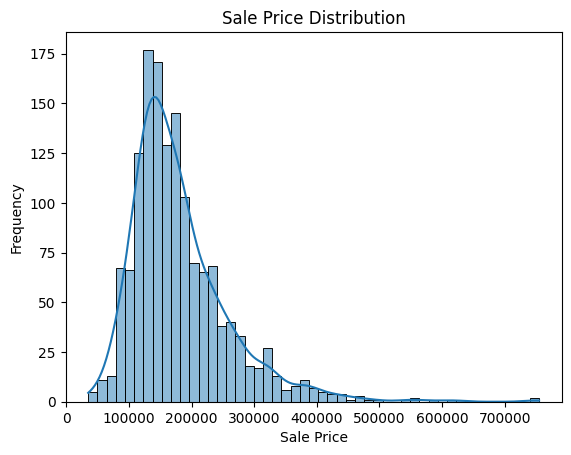

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Visualizing distribution
sns.histplot(housing_data_train['SalePrice'], kde=True)
plt.title("Sale Price Distribution")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.show()

#Log-Transform Target to make target more normal which improves performance

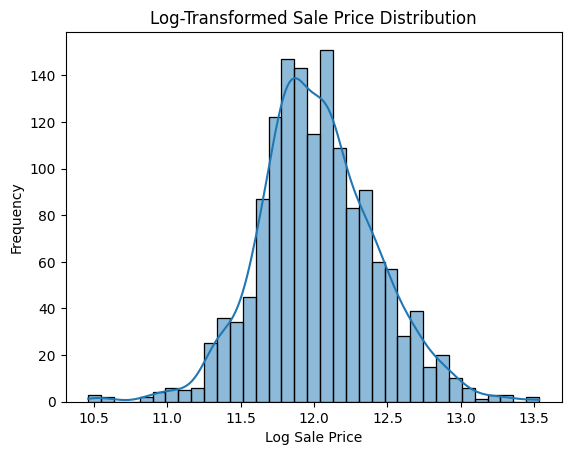

In [58]:
housing_data_train["LogSalePrice"] = np.log1p(housing_data_train["SalePrice"])

housing_data_test['SalePrice'] = np.nan
housing_data_test['LogSalePrice'] = np.nan

sns.histplot(housing_data_train["LogSalePrice"], kde=True)
plt.title("Log-Transformed Sale Price Distribution")
plt.xlabel("Log Sale Price")
plt.ylabel("Frequency")
plt.show()

#Q-Q plot to check for normality

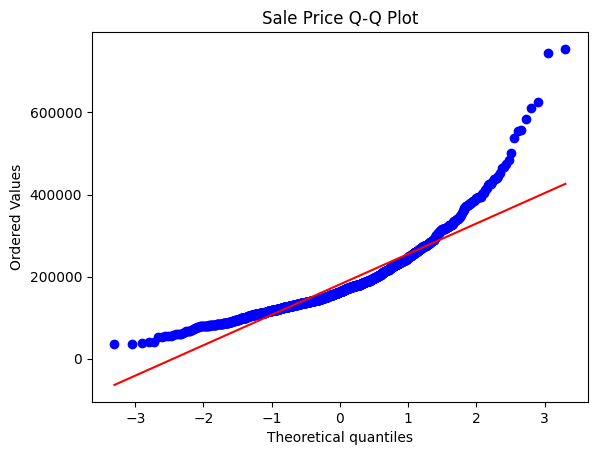

In [59]:
from scipy import stats
fig = plt.figure()
res = stats.probplot(housing_data_train["SalePrice"], plot=plt)
plt.title("Sale Price Q-Q Plot")
plt.show()

#Let's check the same Q-Q plot with Log sale price

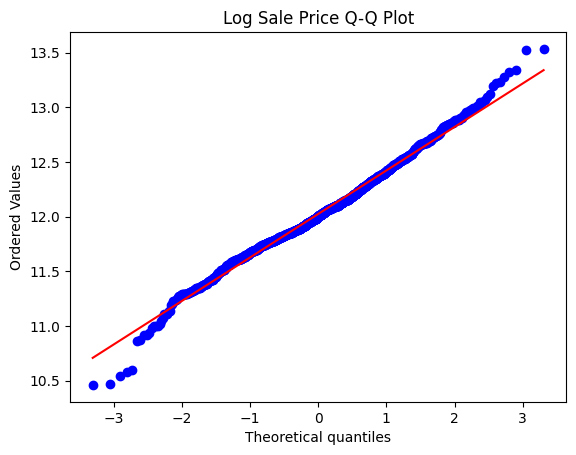

In [60]:
fig = plt.figure()
res = stats.probplot(housing_data_train["LogSalePrice"], plot=plt)
plt.title("Log Sale Price Q-Q Plot")
plt.show()

#Identifying columns with missing values

In [61]:
missing_train = housing_data_train.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)

missing_test = housing_data_test.isnull().sum()
missing_test = missing_test[missing_test > 0].sort_values(ascending=False)

print(missing_train)
print(missing_test)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64
SalePrice       1459
LogSalePrice    1459
PoolQC          1456
MiscFeature     1408
Alley           1352
Fence           1169
MasVnrType       894
FireplaceQu      730
LotFrontage      227
GarageYrBlt       78
GarageFinish      78
GarageCond        78
GarageQual        78
GarageType        76
BsmtCond          45
BsmtExposure      44
BsmtQual          44
BsmtFinType1      42
BsmtFinType2      42
MasVnrArea        15
MSZoning           4
Utilities          2
Functional         2
BsmtHalfBath       2
BsmtFullBath       2
Exterior2nd        1
Exterior1st        1
BsmtUnfSF          1


#Combining Train and Test data for combined preprocessing so it is consistent

In [62]:
housing_data_train["TrainFlag"] = 1
housing_data_test["TrainFlag"] = 0

combined_housing_data = pd.concat([housing_data_train, housing_data_test], axis=0)
print(combined_housing_data.columns.tolist())

['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC'

#Data cleaning
#1 Dropping overly sparse features
#2 Avoid NaNs which break models
#3 Mode/median imputation which avoids data leakage while preserving distribution

In [63]:
#Dropping columns with greater than 30% of missing values
null_pct = combined_housing_data.isnull().mean()
drop_columns = null_pct[null_pct > 0.3].index.tolist()
drop_columns = [col for col in drop_columns if col not in ['Id', 'SalePrice', 'LogSalePrice', 'TrainFlag']]
combined_housing_data.drop(columns = drop_columns, inplace=True)

#Imputing categorical with mode and numerical with mean
for col in combined_housing_data.columns:
  if combined_housing_data[col].dtype == 'object':
    combined_housing_data[col].fillna(combined_housing_data[col].mode()[0], inplace=True)
  elif combined_housing_data[col].dtype in ['float64', 'int64']:
    combined_housing_data[col].fillna(combined_housing_data[col].median(), inplace=True)
print(combined_housing_data.columns.tolist())

['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SaleType', 'Sa

#Feature engineering

In [64]:
#New combined feature examples
combined_housing_data["TotalSF"] = combined_housing_data["TotalBsmtSF"] + combined_housing_data["1stFlrSF"] + combined_housing_data["2ndFlrSF"]
combined_housing_data["TotalPorchSF"] = combined_housing_data["OpenPorchSF"] + combined_housing_data["EnclosedPorch"] + combined_housing_data["3SsnPorch"] + combined_housing_data["ScreenPorch"]
combined_housing_data["TotalBath"] = (combined_housing_data["FullBath"] + 0.5 * combined_housing_data['HalfBath'] + combined_housing_data['BsmtFullBath'] + 0.5 * combined_housing_data['BsmtHalfBath'])
combined_housing_data["Age"] = combined_housing_data['YrSold'] - combined_housing_data['YearBuilt']
combined_housing_data["RemodAge"] = combined_housing_data['YrSold'] - combined_housing_data['YearRemodAdd']
combined_housing_data["HasGarage"] = combined_housing_data['GarageArea'].apply(lambda x: 1 if x>0 else 0)
combined_housing_data["HasBasement"] = combined_housing_data['TotalBsmtSF'].apply(lambda x: 1 if x>0 else 0)

In [65]:
# Define mappings for ordinal features
qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}
bsmt_expo_map = {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'None': 0}
bsmt_fin_map = {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0}
garage_fin_map = {'Fin': 3, 'RFn': 2, 'Unf': 1, 'None': 0}
paved_drive_map = {'Y': 2, 'P': 1, 'N': 0}
street_map = {'Grvl': 0, 'Pave': 1}
alley_map = {'Grvl': 0, 'Pave': 1, 'None': 2} # Or 0, 1, 2 depending on interpretation

# Apply mappings
for col in ['ExterQual', 'ExterCond', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']:
    if col in combined_housing_data.columns:
        combined_housing_data[col] = combined_housing_data[col].map(qual_map).fillna(0) # Fillna for cases not in map (e.g., missing values)
if 'BsmtExposure' in combined_housing_data.columns:
    combined_housing_data['BsmtExposure'] = combined_housing_data['BsmtExposure'].map(bsmt_expo_map).fillna(0)
for col in ['BsmtFinType1', 'BsmtFinType2']:
    if col in combined_housing_data.columns:
        combined_housing_data[col] = combined_housing_data[col].map(bsmt_fin_map).fillna(0)
if 'GarageFinish' in combined_housing_data.columns:
    combined_housing_data['GarageFinish'] = combined_housing_data['GarageFinish'].map(garage_fin_map).fillna(0)
if 'PavedDrive' in combined_housing_data.columns:
    combined_housing_data['PavedDrive'] = combined_housing_data['PavedDrive'].map(paved_drive_map).fillna(0)
if 'Street' in combined_housing_data.columns:
    combined_housing_data['Street'] = combined_housing_data['Street'].map(street_map).fillna(0)
if 'Alley' in combined_housing_data.columns:
    combined_housing_data['Alley'] = combined_housing_data['Alley'].map(alley_map).fillna(0)

# Handle 'Functional'
functional_map = {'Typ': 7, 'Min1': 6, 'Min2': 5, 'Mod': 4, 'Maj1': 3, 'Maj2': 2, 'Sev': 1, 'Sal': 0}
if 'Functional' in combined_housing_data.columns:
    combined_housing_data['Functional'] = combined_housing_data['Functional'].map(functional_map).fillna(functional_map['Typ'])

#Encoding Categorical Variables

In [66]:
combined_housing_data = pd.get_dummies(combined_housing_data, drop_first=True)
print(housing_data_train.columns.tolist())

['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC'

#Split back and prepare for modeling

In [67]:
housing_data_train = combined_housing_data[combined_housing_data['TrainFlag'] == 1].copy()
housing_data_test = combined_housing_data[combined_housing_data['TrainFlag'] == 0].copy()

housing_data_train.drop(columns=['TrainFlag'], inplace=True)
housing_data_test.drop(columns=['TrainFlag'], inplace=True)

X = housing_data_train.drop(columns=['Id', 'SalePrice', 'LogSalePrice'])
y = housing_data_train['LogSalePrice']

X_test = housing_data_test[X.columns]

#Train-Test Split and scaling

In [68]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

#Avoids overfitting by keeping a validation set
#Scaling ensures features contribute equally

#Regularized Linear Regression

In [70]:
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score

#Ridge: better when many small/medium features matter
ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_val_scaled)
ridge_rmse = np.sqrt(mean_squared_error(y_val, y_pred_ridge))

#Lasso: also performs feature selection
lasso = LassoCV(alphas=np.logspace(-3, 3, 50), cv=5, max_iter=10000)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_val_scaled)
lasso_rmse = np.sqrt(mean_squared_error(y_val, y_pred_lasso))

#Ridge Cross-validated RMSE
ridge_cv_scores = -cross_val_score(ridge, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
ridge_cv_rmse = np.sqrt(ridge_cv_scores.mean())

#Lasso Cross-validated RMSE
lasso_cv_scores = -cross_val_score(lasso, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
lasso_cv_rmse = np.sqrt(lasso_cv_scores.mean())

#ElasticNet Cross-validated RMSE
from sklearn.linear_model import ElasticNetCV
elastic_net = ElasticNetCV(alphas=np.logspace(-3, 3, 50), l1_ratio=[.1, .5, .7, .9, .95], cv=5, max_iter=10000)
elastic_net.fit(X_train_scaled, y_train)
y_pred_elastic_net = elastic_net.predict(X_val_scaled)
elastic_net_rmse = np.sqrt(mean_squared_error(y_val, y_pred_elastic_net))
elastic_net_cv_scores = -cross_val_score(elastic_net, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
elastic_net_cv_rmse = np.sqrt(elastic_net_cv_scores.mean())

print(f"Elastic RMSE: {elastic_net_rmse}")
print(f"Ridge RMSE: {ridge_rmse}")
print(f"Lasso RMSE: {lasso_rmse}")

print(f"Ridge CV RMSE: {ridge_cv_rmse}")
print(f"Lasso CV RMSE: {lasso_cv_rmse}")
print(f"ElasticNet CV RMSE: {elastic_net_cv_rmse}")

#Ridge(L2) shrinks coefficients, handles collinearity
#Lasso(L1) also performs feature selection
#These prevent overfitting in higher dimentional data

Elastic RMSE: 0.1423656093681337
Ridge RMSE: 0.14404004291774689
Lasso RMSE: 0.14031015154713258
Ridge CV RMSE: 0.14887595059255976
Lasso CV RMSE: 0.15510480407387442
ElasticNet CV RMSE: 0.15115133798536273


#Compare feature Importances(Coefficients)

In [71]:
coef_df = pd.DataFrame({'Feature': X_train.columns, 'Ridge_Coef': ridge.coef_, 'Lasso_Coef': lasso.coef_, 'ElasticNet_Coeff': elastic_net.coef_})

print(coef_df.set_index('Feature').round(4))

                       Ridge_Coef  Lasso_Coef  ElasticNet_Coeff
Feature                                                        
MSSubClass                -0.0098     -0.0186           -0.0135
LotFrontage               -0.0002     -0.0000           -0.0000
LotArea                    0.0097      0.0124            0.0116
Street                     0.0009     -0.0000            0.0000
OverallQual                0.0445      0.0910            0.0812
...                           ...         ...               ...
SaleCondition_AdjLand      0.0014     -0.0000           -0.0000
SaleCondition_Alloca       0.0097      0.0009            0.0000
SaleCondition_Family      -0.0020     -0.0000           -0.0000
SaleCondition_Normal       0.0089      0.0013            0.0000
SaleCondition_Partial      0.0079      0.0099            0.0049

[203 rows x 3 columns]


#Select best model and predict on test data

In [72]:
best_model_name = min(
    {'Ridge': ridge_cv_rmse, 'Lasso': lasso_cv_rmse, 'ElasticNet': elastic_net_cv_rmse},
    key=lambda x: {'Ridge': ridge_cv_rmse, 'Lasso': lasso_cv_rmse, 'ElasticNet': elastic_net_cv_rmse}[x])

best_model = {'Ridge': ridge, 'Lasso': lasso, 'ElasticNet': elastic_net}[best_model_name]
test_scaled = scaler.transform(housing_data_test[X.columns])

final_predictions = np.expm1(best_model.predict(test_scaled))

submission = pd.DataFrame({'Id': housing_data_test['Id'], 'SalePrice': final_predictions})

submission.to_csv('submission.csv', index=False)

In [73]:
from google.colab import files
files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>